In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split

path = os.getcwd()
while ".git" not in os.listdir(path):
    path = os.path.dirname(path)
ROOT_DIR = Path(path)
os.chdir(ROOT_DIR)

from scripts.helpers.modelling import prepare_modelling

In [2]:
df = prepare_modelling(resolution=6, freq='3h')

### Train Test Split

In [3]:
ID_cols = ['h3_id', 'time_bucket']

x = df.drop(columns=['trip_count', *ID_cols, 'hour', 'day_of_week', 'month'])
ids = df[ID_cols]
y = df['trip_count']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)
x_train, x_hold, y_train, y_hold = train_test_split(x_train, y_train, test_size=(0.2/0.7), random_state=1)

print(len(x_train), len(x_hold), len(x_test))

88503 35402 53103


In [4]:
x.info()

<class 'pandas.DataFrame'>
RangeIndex: 177008 entries, 0 to 177007
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   day                   177008 non-null  Int64  
 1   week                  177008 non-null  Int64  
 2   is_weekend            177008 non-null  bool   
 3   is_holiday            177008 non-null  bool   
 4   hour_sin              177008 non-null  Float64
 5   hour_cos              177008 non-null  Float64
 6   day_of_week_sin       177008 non-null  Float64
 7   day_of_week_cos       177008 non-null  Float64
 8   month_sin             177008 non-null  Float64
 9   month_cos             177008 non-null  Float64
 10  temperature_2m        177008 non-null  float64
 11  apparent_temperature  177008 non-null  float64
 12  precipitation         177008 non-null  float64
 13  rain                  177008 non-null  float64
 14  snowfall              177008 non-null  float64
 15  snow_depth 

## Lasso Feature Selection

In [5]:
# feature selection with Lasso to rank cyclic and lag features
from sklearn.linear_model import LassoCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

lasso_features = x

lasso_selector = make_pipeline(StandardScaler(), LassoCV(cv=5, random_state=1))
lasso_selector.fit(x_train[lasso_features.columns], y_train)

lasso_coefs = lasso_selector.named_steps['lassocv'].coef_
threshold = 0.0
selected_features = [feat for feat, coef in zip(lasso_features.columns, lasso_coefs) if abs(coef) > threshold]

feature_importance = pd.DataFrame({
    'feature': lasso_features.columns,
    'coef': lasso_coefs,
    'abs_coef': np.abs(lasso_coefs)
}).sort_values('abs_coef', ascending=False)

if selected_features:
    x_train = x_train[selected_features]
    x_hold = x_hold[selected_features]
    x_test = x_test[selected_features]
else:
    x_train = x_train.copy()
    x_hold = x_hold.copy()
    x_test = x_test.copy()

print("Selected features (|coef| > 0.0):", selected_features)
feature_importance

Selected features (|coef| > 0.0): ['day', 'week', 'is_weekend', 'is_holiday', 'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos', 'month_sin', 'month_cos', 'temperature_2m', 'apparent_temperature', 'rain', 'snowfall', 'snow_depth', 'windspeed_10m', 'windgusts_10m', 'cloud_cover']


c:\Users\Daniel\AAA\AAA26-Chicago-Mobility\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.032e+05, tolerance: 2.473e+05
  model = cd_fast.enet_coordinate_descent(


,feature,coef,abs_coef
5,hour_cos,-22.216490,22.216490
10,temperature_2m,-11.853358,11.853358
11,apparent_temperature,8.506029,8.506029
4,hour_sin,-6.260481,6.260481
2,is_weekend,-5.934223,5.934223
9,month_cos,-5.392064,5.392064
1,week,5.271375,5.271375
16,windspeed_10m,3.053389,3.053389
8,month_sin,3.007573,3.007573
3,is_holiday,-3.007172,3.007172


C:\Users\Daniel\AppData\Local\Temp\ipykernel_10128\2512387465.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance, x='abs_coef', y='feature', palette='viridis')


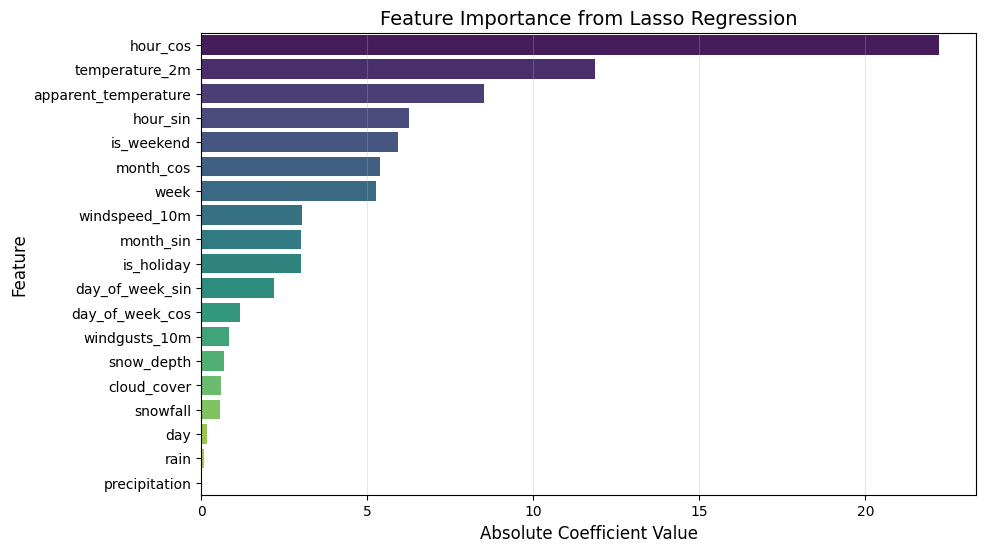

In [6]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance, x='abs_coef', y='feature', palette='viridis')
plt.title('Feature Importance from Lasso Regression', fontsize=14)
plt.xlabel('Absolute Coefficient Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.show()